# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name:**  Khadija Shahid
**Student ID:**  023-24-0010
**Section:** BSCS-AI(B)
**GitHub:**
**Kaggle:**
**Dataset:** Telco Customer Churn (Kaggle)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [5]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [6]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split

df = pd.read_csv("clean_churn.csv")

# Define target
Y = df["Churn"].map({"No": 0, "Yes": 1})

# Define features
X = df.drop(columns=["Churn"])

# Convert categorical columns to numeric
X = pd.get_dummies(X, dtype=int)

# Train/test split — same as Lab 3
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)


X shape: (7032, 45)
Y shape: (7032,)
X_train shape: (5625, 45)
X_test shape: (1407, 45)
Y_train shape: (5625,)
Y_test shape: (1407,)


In [3]:
# Task 2 — retrain Lab 3 Decision Tree, report test-set metrics


# Train the best Decision Tree from Lab 3
tree_model=DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train,Y_train)

# Make predictions on the test set
tree_pred=tree_model.predict(X_test)

#calaculate the evaluation metrices

tree_accuracy=accuracy_score(Y_test,tree_pred)
tree_precision=precision_score(Y_test,tree_pred)
tree_recall=recall_score(Y_test,tree_pred)
tree_f1=f1_score(Y_test,tree_pred)


print("Decision Tree Baseline Metrics")
print("Accuracy:", tree_accuracy)
print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1-score:", tree_f1)



Decision Tree Baseline Metrics
Accuracy: 0.7896233120113717
Precision: 0.6020942408376964
Recall: 0.6149732620320856
F1-score: 0.6084656084656085


**Task 2 — Decision Tree Baseline Metrics**

| Metric | Value |
|---|---|
| Accuracy | 78.96%|
| Precision | 60.21%|
| Recall | 61.50%|
| F1-score |60.85% |

---

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [7]:
# Task 3 — train Random Forest, predict on test set

rf_model=RandomForestClassifier( random_state=42)

rf_model.fit(X_train,Y_train)

#make predictions
rf_pred=rf_model.predict(X_test)

print("Random Forest Predictions:")
print("Number Of Predictions", len(rf_pred))


Random Forest Predictions:
Number Of Predictions 1407


**Answer 4:**
Random Forest may generalize better because it does not rely on single tree but combines predictions from the multiple decision tree instead of relying on single tree. This can help to reduce the overfitting.

---

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

In [8]:
# Task 5 — Random Forest metrics + confusion matrix

rf_accuracy=accuracy_score(Y_test,rf_pred)
rf_precision=precision_score(Y_test,rf_pred)
rf_recall=recall_score(Y_test,rf_pred)
rf_f1=f1_score(Y_test,rf_pred)

print("Random Forest Metrics")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1) 




Random Forest Metrics
Accuracy: 0.7903340440653873
Precision: 0.6376306620209059
Recall: 0.4893048128342246
F1-score: 0.5537065052950075


**Task 5 — Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy | 79.3%|
| Precision |63.76 |
| Recall |48.93% |
| F1-score |55.37% |

**Observation (confusion matrix):**
The Random Forest achieved an accuracy of 79.03% and precision of 63.76%, while its recall was 48.93% and F1-score was 55.37%. The model has slightly higher accuracy and precision than the Decision Tree, but its recall and F1-score are lower. This means the Random Forest was better at precision but detected fewer actual churn cases.

---

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

**Task 6 — Comparison Table**

| Metric | Decision Tree | Random Forest |
|---|---|---|
| Accuracy | 0.7896|0.7093 |
| Precision |0.6021 |0.6376 |
| Recall |0.6150 |0.4893 |
| F1-score | 0.6085|0.5537 |

**Answer 7:**
The Random Forest performs slightly better in accuracy (79.03%) and precision (63.76%), while the Decision Tree performs better in recall (61.50%) and F1-score (60.85%). The difference in accuracy is very small, so it is marginal, while the difference in recall and F1-score is more noticeable. Because the dataset has a class imbalance, recall and F1-score are important metrics because they show how well the models identify customers who actually churn. Based on these metrics, the Decision Tree performs better overall than the Random Forest in the current results.

---

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [12]:
# Task 8 — 5-fold cross-validation for both models

## Task 8 — 5-fold cross-validation for both models

# Decision Tree Cross Validation
tree_cv_scores = cross_val_score(
    tree_model,
    X,
    Y,
    cv=5,
    scoring="f1"
)

# Random Forest Cross Validation
rf_cv_scores = cross_val_score(
    rf_model,
    X,
    Y,
    cv=5,
    scoring="f1"
)

print("Decision Tree CV F1 Scores:", tree_cv_scores)
print("Decision Tree Mean F1:", tree_cv_scores.mean())
print("Decision Tree Std F1:", tree_cv_scores.std())

print("\nRandom Forest CV F1 Scores:", rf_cv_scores)
print("Random Forest Mean F1:", rf_cv_scores.mean())
print("Random Forest Std F1:", rf_cv_scores.std())



Decision Tree CV F1 Scores: [0.61246612 0.62382865 0.59337748 0.58992806 0.57720058]
Decision Tree Mean F1: 0.5993601781569045
Decision Tree Std F1: 0.016650989737622402

Random Forest CV F1 Scores: [0.56752656 0.55505279 0.52459016 0.53605016 0.56402439]
Random Forest Mean F1: 0.5494488113303997
Random Forest Std F1: 0.01654166380295866


**Task 8 — Cross-Validation Results**

| Model | Mean F1 | Std F1 |
|---|---|---|
| Decision Tree |59.94% |1.665% |
| Random Forest | 54.94%| 1.654%|

**Answer 9:**
The cross-validation results support the conclusion from the single train/test split that the Decision Tree performs better overall than the Random Forest when using F1-score. The Decision Tree achieved a mean F1-score of 59.94% with a standard deviation of 1.67%, while the Random Forest achieved a mean F1-score of 54.94% with a standard deviation of 1.65%. The cross-validation results give more confidence in the comparison because they evaluate both models across five different folds instead of relying on only one train/test split.

---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [15]:
# Task 10 — define a small param grid and run GridSearchCV / RandomizedSearchCV

param_grid = {
    "n_estimators": [100,200],   #trees number 
    "max_depth":[5,10,None],
    "min_samples_split":[2,5]
}

grid_search=GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
)

grid_search.fit(X_train,Y_train)

print("Best Parameters",grid_search.best_params_)
print("Best CV F1 Score:",grid_search.best_score_)


Best Parameters {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.5846500014916819


**Answer 11 (best hyperparameters & CV score):**
The best Random Forest parameters found through GridSearchCV were max_depth=10, min_samples_split=5, and n_estimators=200. The best cross-validated F1-score was 0.58465, or approximately 58.47%.

In [16]:
# Task 12 — evaluate the tuned model on the test set

tuned_rf=grid_search.best_estimator_

tuned_rf_pred=tuned_rf.predict(X_test)
tuned_rf_accuracy=accuracy_score(Y_test,tuned_rf_pred)
tuned_rf_precision = precision_score(Y_test, tuned_rf_pred)
tuned_rf_recall = recall_score(Y_test, tuned_rf_pred)
tuned_rf_f1 = f1_score(Y_test, tuned_rf_pred)

print("Tuned Random Forest Metrics")
print("Accuracy:", tuned_rf_accuracy)
print("Precision:", tuned_rf_precision)
print("Recall:", tuned_rf_recall)
print("F1-score:", tuned_rf_f1)





Tuned Random Forest Metrics
Accuracy: 0.7931769722814499
Precision: 0.6360655737704918
Recall: 0.5187165775401069
F1-score: 0.5714285714285714


**Task 12 — Tuned Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy |79.31% |
| Precision | 63.60%|
| Recall | 51.87%|
| F1-score | 57.14%|

---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

**Task 13 — Final Comparison Table**

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---|---|---|
| Accuracy |78.96% | 79.03%| 79.31%|
| Precision |60.21 | 63.76%|63.60% |
| Recall |61.50 | 48.93%|51.87% |
| F1-score |60.85% | 55.37%|57.14% |

---

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

Top 5 Most Important Features:
MonthlyCharges                 0.035825
tenure                         0.069048
TotalCharges                   0.119405
InternetService_Fiber optic    0.151209
Contract_Month-to-month        0.522339
dtype: float64


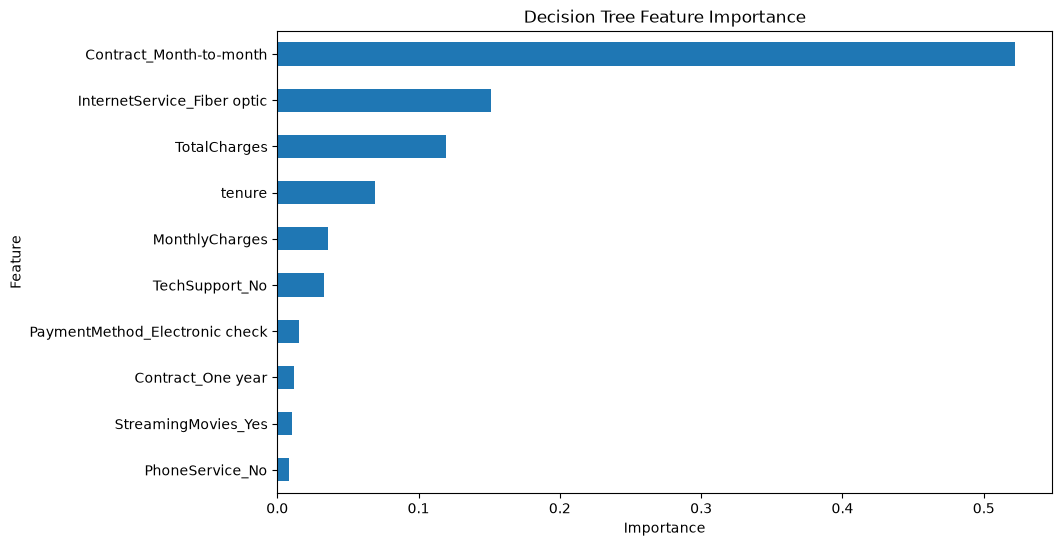

In [17]:
# Task 14 — extract and visualize feature importances

# Use the Decision Tree as the best-performing model
best_model = tree_model

# Get feature importances
importances = best_model.feature_importances_

# Create a Series with feature names
feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=True)

# Display top 5 features
print("Top 5 Most Important Features:")
print(feature_importance.tail(5))

# Plot feature importances
plt.figure(figsize=(10, 6))
feature_importance.tail(10).plot(kind="barh")

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()



**Answer 14:**
_(your answer here)_

---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
I would select the Decision Tree as the final model. It achieved a higher recall and F1-score than the default Random Forest, with an F1-score of 60.85% compared with 55.37%. The cross-validation results also supported the Decision Tree, which had a higher mean F1-score of 59.94% compared with 54.94% for the Random Forest.

---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [19]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [20]:
# Task 16 — Create and save submission file

# Generate predictions using the final Decision Tree model
final_predictions = tree_model.predict(X_test)

# Create submission DataFrame
submission = pd.DataFrame({
    "Churn": final_predictions
})

# Convert predictions from 0/1 back to No/Yes
submission["Churn"] = submission["Churn"].map({
    0: "No",
    1: "Yes"
})

# Save the submission file
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")
print("\nFirst 5 predictions:")
print(submission.head())

print("\nSubmission shape:", submission.shape)

Submission file created successfully!

First 5 predictions:
  Churn
0    No
1   Yes
2    No
3    No
4    No

Submission shape: (1407, 1)


---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
The Decision Tree and Random Forest models were compared using accuracy, precision, recall, and F1-score. The Decision Tree achieved an accuracy of 78.96% and an F1-score of 60.85%, while the default Random Forest achieved an accuracy of 79.03% and an F1-score of 55.37%. The cross-validation results also showed that the Decision Tree had a higher mean F1-score of 59.94% compared with 54.94% for the Random Forest. Based on the comparison, the Decision Tree was selected as the final model because it performed better on recall and F1-score. The final Decision Tree was then used to generate 1,407 churn predictions for the submission file.

**Answer 18 — Next steps:**
Possible next steps include further hyperparameter tuning and exploring additional model configurations. The models could also be compared using other evaluation approaches to determine whether performance can be improved.


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Section 1 — Decision Tree Baseline
- [ ] Section 2 — Random Forest
- [ ] Section 3 — Model Evaluation
- [ ] Section 4 — Decision Tree vs Random Forest
- [ ] Section 5 — Cross-Validation
- [ ] Section 6 — Hyperparameter Tuning
- [ ] Section 7 — Final Model Comparison
- [ ] Section 8 — Feature Importance
- [ ] Section 9 — Final Model Selection (justified)
- [ ] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted